In [1]:
%pip install matplotlib

  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.3 MB 7.0 MB/s eta 0:00:02
   ----------- ---------------------------- 2.6/9.3 MB 6.5 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.3 MB 6.8 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.3 MB 7.1 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.3 MB 7.3 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 7.4 MB/s  0:00:01
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   --------

In [2]:
# env:attiny85

# NOTE: measurements taken with the attiny driving the EN pin of the 
# TPS63020, which has *considerably* higher quiescent current than 
# switching GND of the TPS63020 with a MOSFET.
# with the second option, current at 3.3 V is about 4 uA, but i didn't measure much more than that.
measurements = {
  1.8: 7.2, # at 1.8 V, 4.3 uA
  2.0: 8.0,
  2.5: 9.8,
  3.0: 12.0,
  3.3: 13.5,
  3.5: 14.4,
  4.0: 17.1,
  4.5: 19.8,
  5.0: 22.9,
}

Voltage (V) | Current (uA) | Estimated Runtime
--------------------------------------------------
1.8          | 7.2          | 24.11 years 
2.0          | 8.0          | 21.70 years 
2.5          | 9.8          | 17.72 years 
3.0          | 12.0         | 14.47 years 
3.3          | 13.5         | 12.86 years 
3.5          | 14.4         | 12.06 years 
4.0          | 17.1         | 10.15 years 
4.5          | 19.8         | 8.77 years  
5.0          | 22.9         | 7.58 years  



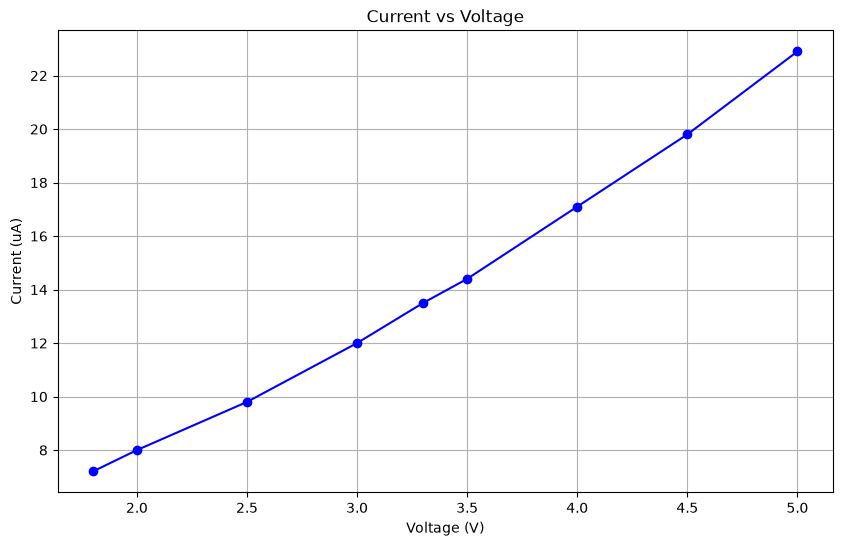

In [3]:
battery_capacity = 1500 # mAh
battery_capacity *= 1000 # convert to uAh


# Calculate estimated battery runtime in hours
runtime_hours = {v: battery_capacity / uA if uA != 0 else 0 for v, uA in measurements.items()}

# Convert runtime to appropriate units (days, months, years)
def convert_runtime(hours):
  days = hours / 24
  if days < 30:
    return f"{days:.2f} days"
  months = days / 30
  if months < 12:
    return f"{months:.2f} months"
  years = months / 12
  return f"{years:.2f} years"

# Create a table for better visualization
table = "Voltage (V) | Current (uA) | Estimated Runtime\n"
table += "-" * 50 + "\n"

for v in measurements:
  runtime_str = convert_runtime(runtime_hours[v])
  table += f"{v:<12} | {measurements[v]:<12} | {runtime_str:<12}\n"

# Display the table
print(table)



import matplotlib.pyplot as plt

# Extract voltage and current values
voltages = list(measurements.keys())
currents = list(measurements.values())

# Plot current vs voltage
plt.figure(figsize=(10, 6))
plt.plot(voltages, currents, marker='o', linestyle='-', color='b')
plt.title('Current vs Voltage')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (uA)')
plt.grid(True)
plt.show()
